In [3]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Admin\Downloads\financial_dataset.csv")
df.head()

,Date,Stock_Open,Stock_Close,Stock_High,Stock_Low,Volume,Market_Index,Revenue_Million,COGS_Million,Operating_Expenses_Million,Net_Income_Million,EPS,Total_Assets_Million,Total_Liabilities_Million,Shareholder_Equity_Million,Operating_Cash_Flow_Million,Investing_Cash_Flow_Million,Financing_Cash_Flow_Million
0,2015-01-01,44.57,48.17,49.61,42.10,2078302,1992.58,837.31,479.88,128.9,123.94,3.8,5328.85,3020.83,2648.35,206.64,-126.01,-30.89
1,2015-01-02,55.04,57.47,58.50,54.91,3546533,1996.36,837.31,479.88,128.9,123.94,3.8,5328.85,3020.83,2648.35,206.64,-126.01,-30.89
2,2015-01-05,51.53,57.02,58.26,49.11,5512806,1995.00,837.31,479.88,128.9,123.94,3.8,5328.85,3020.83,2648.35,206.64,-126.01,-30.89
3,2015-01-06,42.64,43.42,47.46,41.85,4197418,2005.62,837.31,479.88,128.9,123.94,3.8,5328.85,3020.83,2648.35,206.64,-126.01,-30.89
4,2015-01-07,47.34,48.10,48.96,46.81,3593538,2004.61,837.31,479.88,128.9,123.94,3.8,5328.85,3020.83,2648.35,206.64,-126.01,-30.89


In [4]:
df.isnull().sum()

# Option 1: Drop missing rows
df = df.dropna()



In [5]:
print(df.columns)

Index(['Date', 'Stock_Open', 'Stock_Close', 'Stock_High', 'Stock_Low',
       'Volume', 'Market_Index', 'Revenue_Million', 'COGS_Million',
       'Operating_Expenses_Million', 'Net_Income_Million', 'EPS',
       'Total_Assets_Million', 'Total_Liabilities_Million',
       'Shareholder_Equity_Million', 'Operating_Cash_Flow_Million',
       'Investing_Cash_Flow_Million', 'Financing_Cash_Flow_Million'],
      dtype='str')


In [6]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True)

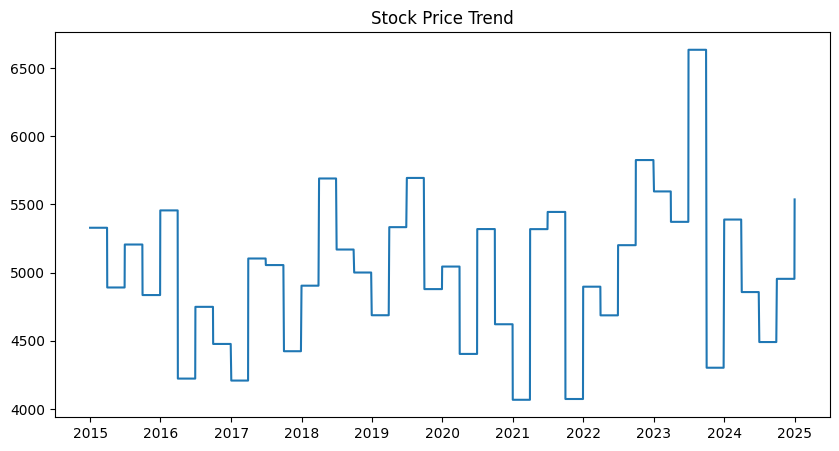

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df['Total_Assets_Million'])
plt.title("Stock Price Trend")
plt.show()

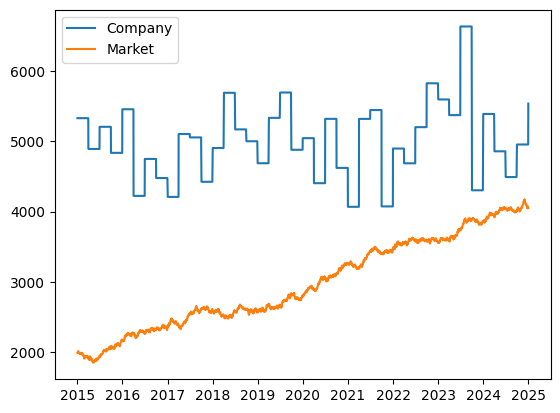

In [8]:
plt.plot(df['Total_Assets_Million'], label='Company')
plt.plot(df['Market_Index'], label='Market')
plt.legend()
plt.show()

<Axes: xlabel='month'>

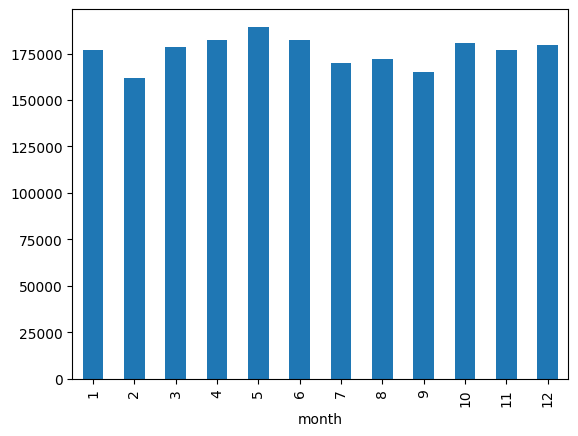

In [9]:
df['month'] = df.index.month
monthly = df.groupby('month')['Revenue_Million'].sum()
monthly.plot(kind='bar')

In [12]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(df['Stock_Close'], order=(1,1,1))
model_fit = model.fit()

forecast = model_fit.forecast(steps=30)
print(forecast)

2025-01-01    200.217071
2025-01-02    199.948353
2025-01-03    199.954342
2025-01-04    199.954209
2025-01-05    199.954212
2025-01-06    199.954212
2025-01-07    199.954212
2025-01-08    199.954212
2025-01-09    199.954212
2025-01-10    199.954212
2025-01-11    199.954212
2025-01-12    199.954212
2025-01-13    199.954212
2025-01-14    199.954212
2025-01-15    199.954212
2025-01-16    199.954212
2025-01-17    199.954212
2025-01-18    199.954212
2025-01-19    199.954212
2025-01-20    199.954212
2025-01-21    199.954212
2025-01-22    199.954212
2025-01-23    199.954212
2025-01-24    199.954212
2025-01-25    199.954212
2025-01-26    199.954212
2025-01-27    199.954212
2025-01-28    199.954212
2025-01-29    199.954212
2025-01-30    199.954212
Freq: D, Name: predicted_mean, dtype: float64


Columns in dataset: Index(['Date', 'Stock_Open', 'Stock_Close', 'Stock_High', 'Stock_Low',
       'Volume', 'Market_Index', 'Revenue_Million', 'COGS_Million',
       'Operating_Expenses_Million', 'Net_Income_Million', 'EPS',
       'Total_Assets_Million', 'Total_Liabilities_Million',
       'Shareholder_Equity_Million', 'Operating_Cash_Flow_Million',
       'Investing_Cash_Flow_Million', 'Financing_Cash_Flow_Million'],
      dtype='str')
            Stock_Open  Stock_Close  Stock_High  Stock_Low   Volume  \
Date                                                                  
2015-01-01       44.57        48.17       49.61      42.10  2078302   
2015-01-02       55.04        57.47       58.50      54.91  3546533   
2015-01-05       51.53        57.02       58.26      49.11  5512806   
2015-01-06       42.64        43.42       47.46      41.85  4197418   
2015-01-07       47.34        48.10       48.96      46.81  3593538   

            Market_Index  Revenue_Million  COGS_Million  \
D

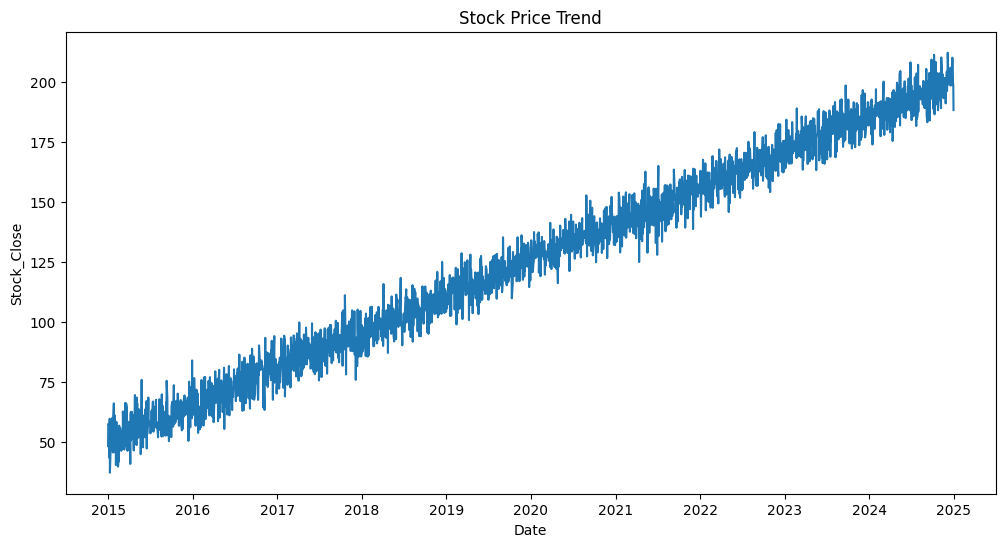

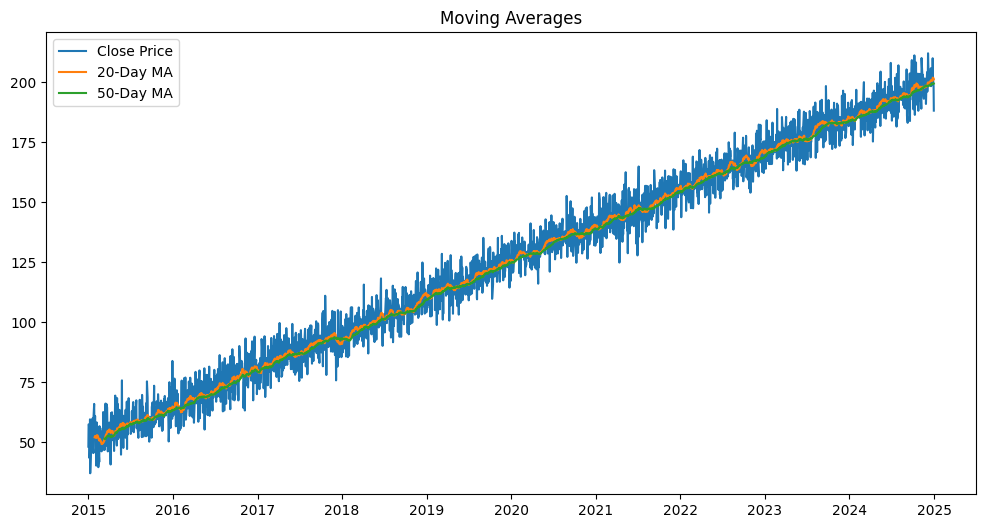

Holt-Winters RMSE: 4.5783844861389715
ARIMA RMSE: 5.26072114143004


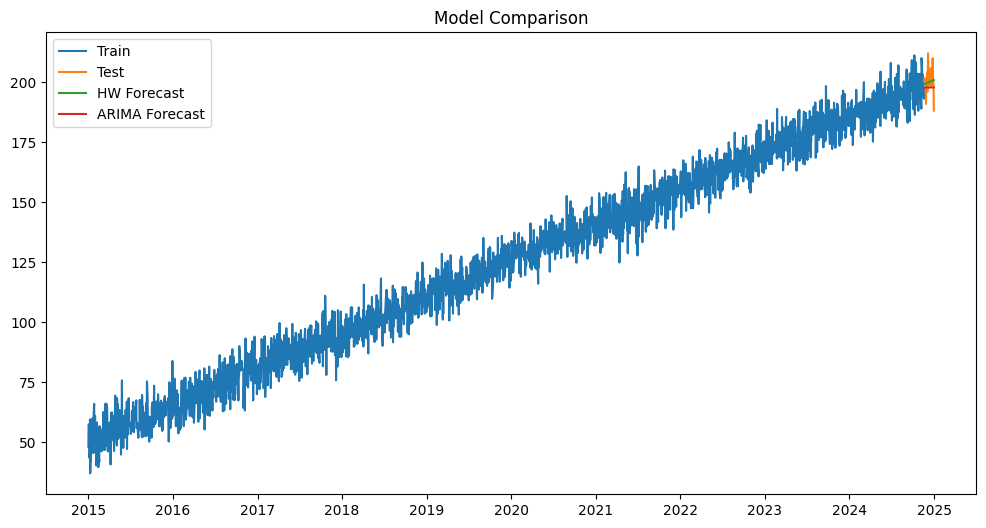

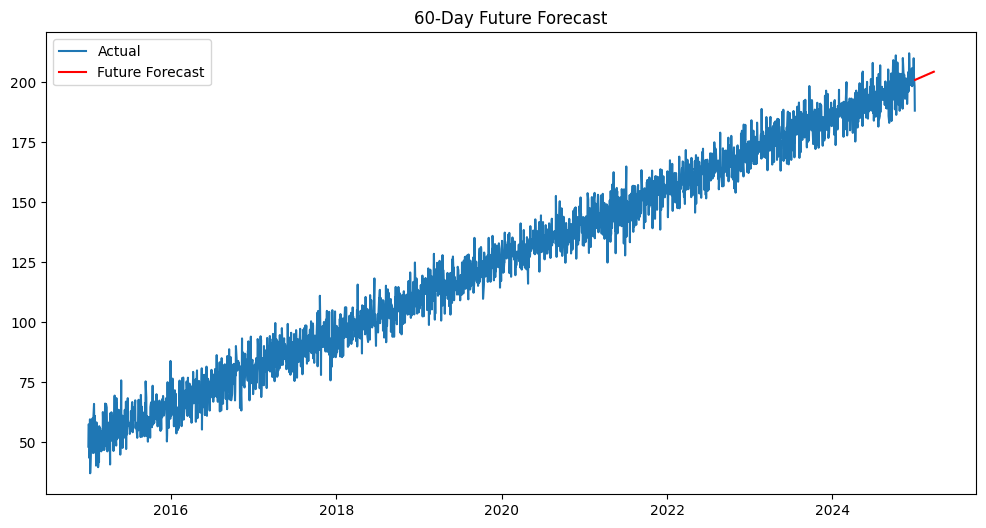

Next 60 Days Forecast:
2025-01-01    200.961850
2025-01-02    201.019583
2025-01-03    201.077316
2025-01-06    201.135049
2025-01-07    201.192782
2025-01-08    201.250515
2025-01-09    201.308248
2025-01-10    201.365981
2025-01-13    201.423714
2025-01-14    201.481447
2025-01-15    201.539180
2025-01-16    201.596913
2025-01-17    201.654646
2025-01-20    201.712379
2025-01-21    201.770112
2025-01-22    201.827845
2025-01-23    201.885578
2025-01-24    201.943311
2025-01-27    202.001044
2025-01-28    202.058777
2025-01-29    202.116510
2025-01-30    202.174243
2025-01-31    202.231975
2025-02-03    202.289708
2025-02-04    202.347441
2025-02-05    202.405174
2025-02-06    202.462907
2025-02-07    202.520640
2025-02-10    202.578373
2025-02-11    202.636106
2025-02-12    202.693839
2025-02-13    202.751572
2025-02-14    202.809305
2025-02-17    202.867038
2025-02-18    202.924771
2025-02-19    202.982504
2025-02-20    203.040237
2025-02-21    203.097970
2025-02-24    203.155703
20

In [20]:
# ==========================================
# 1. Import Libraries
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings("ignore")

# ==========================================
# 2. Load Dataset
# ==========================================
df = pd.read_csv(r"C:\Users\Admin\Downloads\financial_dataset.csv")

# Clean column names
df.columns = df.columns.str.strip()

print("Columns in dataset:", df.columns)

# ==========================================
# 3. Convert Date Column
# ==========================================
# Replace 'Date' below with your actual date column name if different
# Convert Date column properly
df['Date'] = pd.to_datetime(df['Date'])

# Sort
df = df.sort_values('Date')

# Set as index
df.set_index('Date', inplace=True)

# Set frequency
df = df.asfreq('B')

# Fill missing values
df['Stock_Close'] = df['Stock_Close'].ffill()

print(df.head())

# ==========================================
# 4. Exploratory Data Analysis (EDA)
# ==========================================

# Line plot
plt.figure(figsize=(12,6))
plt.plot(df['Stock_Close'])
plt.title("Stock Price Trend")
plt.xlabel("Date")
plt.ylabel("Stock_Close")
plt.show()

# Moving Averages
df['MA_20'] = df['Stock_Close'].rolling(20).mean()
df['MA_50'] = df['Stock_Close'].rolling(50).mean()

plt.figure(figsize=(12,6))
plt.plot(df['Stock_Close'], label='Close Price')
plt.plot(df['MA_20'], label='20-Day MA')
plt.plot(df['MA_50'], label='50-Day MA')
plt.legend()
plt.title("Moving Averages")
plt.show()

# ==========================================
# 5. Train-Test Split
# ==========================================
train = df['Stock_Close'][:-30]
test = df['Stock_Close'][-30:]

# ==========================================
# 6. Holt-Winters Model
# ==========================================
hw_model = ExponentialSmoothing(train, trend='add', seasonal=None)
hw_fit = hw_model.fit()
hw_forecast = hw_fit.forecast(30)

# ==========================================
# 7. ARIMA Model
# ==========================================
arima_model = ARIMA(train, order=(1,1,1))
arima_fit = arima_model.fit()
arima_forecast = arima_fit.forecast(30)

# ==========================================
# 8. Model Evaluation
# ==========================================
hw_rmse = np.sqrt(mean_squared_error(test, hw_forecast))
arima_rmse = np.sqrt(mean_squared_error(test, arima_forecast))

print("Holt-Winters RMSE:", hw_rmse)
print("ARIMA RMSE:", arima_rmse)

# ==========================================
# 9. Plot Forecast Comparison
# ==========================================
plt.figure(figsize=(12,6))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test')
plt.plot(test.index, hw_forecast, label='HW Forecast')
plt.plot(test.index, arima_forecast, label='ARIMA Forecast')
plt.legend()
plt.title("Model Comparison")
plt.show()

# ==========================================
# 10. Final Future Forecast (Next 60 Days)
# ==========================================
final_model = ExponentialSmoothing(df['Stock_Close'], trend='add')
final_fit = final_model.fit()
future_forecast = final_fit.forecast(60)

plt.figure(figsize=(12,6))
plt.plot(df['Stock_Close'], label='Actual')
plt.plot(future_forecast, label='Future Forecast', color='red')
plt.legend()
plt.title("60-Day Future Forecast")
plt.show()

print("Next 60 Days Forecast:")
print(future_forecast)

In [21]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(df['Stock_Close'], order=(1,1,1))
model_fit = model.fit()

forecast = model_fit.forecast(steps=30)
print(forecast)

2025-01-01    200.213129
2025-01-02    200.016182
2025-01-03    200.019400
2025-01-06    200.019347
2025-01-07    200.019348
2025-01-08    200.019348
2025-01-09    200.019348
2025-01-10    200.019348
2025-01-13    200.019348
2025-01-14    200.019348
2025-01-15    200.019348
2025-01-16    200.019348
2025-01-17    200.019348
2025-01-20    200.019348
2025-01-21    200.019348
2025-01-22    200.019348
2025-01-23    200.019348
2025-01-24    200.019348
2025-01-27    200.019348
2025-01-28    200.019348
2025-01-29    200.019348
2025-01-30    200.019348
2025-01-31    200.019348
2025-02-03    200.019348
2025-02-04    200.019348
2025-02-05    200.019348
2025-02-06    200.019348
2025-02-07    200.019348
2025-02-10    200.019348
2025-02-11    200.019348
Freq: B, Name: predicted_mean, dtype: float64


In [22]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model = ExponentialSmoothing(df['Stock_Close'], trend='add', seasonal=None)
fit = model.fit()

forecast = fit.forecast(30)

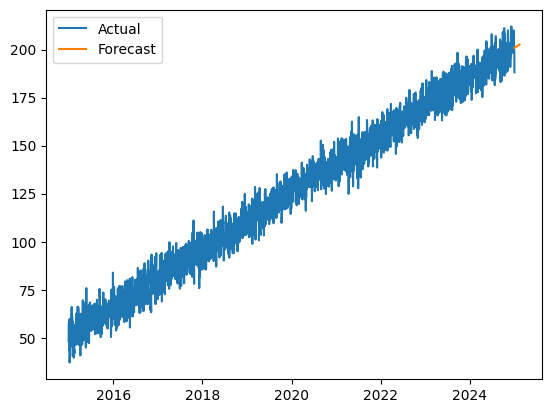

In [23]:
plt.plot(df['Stock_Close'], label='Actual')
plt.plot(forecast, label='Forecast')
plt.legend()
plt.show()